# Softmax Activation Function in Neural Networks

These notes explain:
- Meaning of Softmax activation function
- Formula and working
- Key characteristics
- Why it is used in the last layer
- Step-by-step working
- Graph explanation
- Difference between Sigmoid and Softmax
- Applications, advantages, and challenges
- Python code to visualize Softmax

## 1. What is Softmax Activation Function?

The **Softmax activation function** is used in deep learning to convert a vector of raw scores
(logits) into a **probability distribution**.

It is mainly used in **multi-class classification problems**, where the model has to choose
one class from many possible classes.

### Important properties:
- Each output value lies between **0 and 1**
- The sum of all output values is **1**

So, the output of Softmax can be interpreted as the **probability of each class**.

## 2. Formula of Softmax Function

For an input vector:

z = [z₁, z₂, z₃, ..., zₙ]

the Softmax output for class i is:

σ(zᵢ) = e^(zᵢ) / Σ(e^(zⱼ))   for j = 1 to n

### Where:
- e^(zᵢ) = exponentiation of the input score of class i
- Σ(e^(zⱼ)) = sum of exponentials of all input scores
- σ(zᵢ) = probability of class i

This formula converts the raw scores into normalized probabilities.


## 3. Intuition Behind Softmax

Softmax takes raw outputs from the neural network and changes them into probabilities.

### Example:
Suppose the model outputs logits:

[2.0, 1.0, 0.1]

After applying Softmax, the outputs may become:

[0.659, 0.242, 0.099]

Interpretation:
- Class 1 has probability 65.9%
- Class 2 has probability 24.2%
- Class 3 has probability 9.9%

The largest probability usually becomes the predicted class using **argmax**.


## 4. How Softmax Activation Function Works

Softmax converts raw scores into a probability distribution in the following steps:

### Step 1: Input Scores
Take the raw output vector from the model.
These values can be positive, negative, or zero.

### Step 2: Exponentiation
Apply e^x to each value.
This makes all values positive and increases the difference between them.

### Step 3: Sum of Exponentials
Add all exponentiated values together.

Z = Σ e^(x')

This is the normalizing constant.

### Step 4: Normalize
Divide each exponentiated value by the total sum.

pᵢ = e^(xᵢ) / Z

### Step 5: Output Probabilities
The final vector contains probabilities for all classes.
The sum of these probabilities is always 1.


## 5. Example of Softmax Calculation

Let the input logits be:

z = [2, 1, 0.1]

### Step 1: Exponentiate
e² = 7.389
e¹ = 2.718
e⁰·¹ = 1.105

### Step 2: Sum
Total = 7.389 + 2.718 + 1.105 = 11.212

### Step 3: Normalize
Softmax(z₁) = 7.389 / 11.212 = 0.659
Softmax(z₂) = 2.718 / 11.212 = 0.242
Softmax(z₃) = 1.105 / 11.212 = 0.099

### Final Output:
[0.659, 0.242, 0.099]

This means the first class has the highest probability.


## 6. Key Characteristics of Softmax

### 1. Normalization
Softmax converts logits into probabilities whose sum is exactly 1.

### 2. Exponentiation
Large values become more dominant after exponentiation.
This increases the confidence of the model.

### 3. Differentiable
Softmax is differentiable, so it can be used in backpropagation.

### 4. Probabilistic Interpretation
Each output can be read as the likelihood of a class.

### 5. Interdependent Outputs
Unlike sigmoid, Softmax outputs are connected to each other.
If one probability increases, others must decrease so the total remains 1.


## 7. Why Softmax is Used in the Last Layer

Softmax is commonly used in the **output layer** of a neural network for multi-class classification.

### Reasons:

1. It converts raw model outputs into interpretable probabilities.

2. It is suitable when classes are **mutually exclusive**,
   meaning one input belongs to only one class.

3. It works very well with **categorical cross-entropy loss**,
   which compares predicted probabilities with actual class labels.

### Example:
If a model is classifying an image into:
- Cat
- Dog
- Bird

Softmax gives the probability for each class, and the class with highest probability is selected.


## 8. Graph Explanation of Softmax

Softmax is not usually shown as a single S-shaped curve like Sigmoid or Tanh
because it works on a **vector**, not on a single value.

Instead, Softmax is understood by plotting how probabilities change
when one class score becomes larger than the others.

### Graph idea:
- X-axis: input logit value of one class
- Y-axis: output probability after Softmax

### Interpretation:
- As the logit of one class increases, its probability rises.
- At the same time, the probabilities of other classes decrease.
- The curve shows competition among classes.

So, Softmax behaves like a **probability allocator**:
it gives more probability to the class with the highest score.



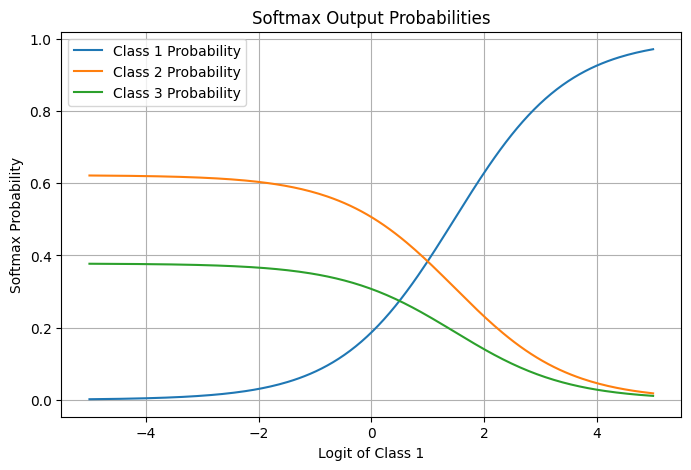

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Softmax function
def softmax(z):
    exp_z = np.exp(z - np.max(z))   # for numerical stability
    return exp_z / np.sum(exp_z)

# Vary the first class logit, keep others fixed
x = np.linspace(-5, 5, 200)

prob_class1 = []
prob_class2 = []
prob_class3 = []

for val in x:
    z = np.array([val, 1.0, 0.5])   # class 2 and class 3 fixed
    probs = softmax(z)
    prob_class1.append(probs[0])
    prob_class2.append(probs[1])
    prob_class3.append(probs[2])

plt.figure(figsize=(8,5))
plt.plot(x, prob_class1, label="Class 1 Probability")
plt.plot(x, prob_class2, label="Class 2 Probability")
plt.plot(x, prob_class3, label="Class 3 Probability")

plt.xlabel("Logit of Class 1")
plt.ylabel("Softmax Probability")
plt.title("Softmax Output Probabilities")
plt.legend()
plt.grid(True)
plt.show()

## 9. Explanation of the Drawn Graph

In this graph:

- The score of **Class 1** changes from -5 to 5
- The scores of **Class 2** and **Class 3** are fixed

### What happens?

- When the score of Class 1 is very small, its probability is near 0
- As its score increases, its probability rises
- Since total probability must stay 1, the probabilities of other classes fall

### Conclusion:
Softmax emphasizes the class with the highest score and suppresses the others.
This is why it is useful for choosing one class among many.4


## 10. Step-by-Step Implementation in Neural Network

### Step 1: Import Libraries
Use NumPy, TensorFlow/Keras, Matplotlib, and Scikit-learn.

### Step 2: Load Dataset
Load a multi-class dataset such as Iris.

### Step 3: One-Hot Encode Labels
Convert class labels into one-hot encoded vectors.

Example:
Class 0 → [1, 0, 0]
Class 1 → [0, 1, 0]
Class 2 → [0, 0, 1]

### Step 4: Build Model
- Hidden layer may use ReLU
- Output layer uses Softmax

### Step 5: Compile Model
Use:
- optimizer = Adam
- loss = categorical_crossentropy
- metric = accuracy

### Step 6: Train Model
Fit the model on training data.

### Step 7: Predict
The output will be a probability vector.
Use argmax to find the predicted class.


## 11. Difference Between Sigmoid and Softmax

| Parameter | Sigmoid | Softmax |
|----------|---------|---------|
| Definition | Maps a single value to range 0 to 1 | Converts a vector into probability distribution |
| Purpose | Binary classification | Multi-class classification |
| Output | Independent probability | Interdependent probabilities |
| Number of Outputs | One probability per neuron | Multiple probabilities across classes |
| Sum of Outputs | Not necessarily 1 | Always 1 |
| Use Case | Two classes | More than two classes |

### Simple understanding:
- **Sigmoid** = "Is this class present or not?"
- **Softmax** = "Which one class is most likely among all classes?"


## 12. Applications of Softmax

### 1. Neural Networks
Used in the final layer of CNNs, MLPs, and other classifiers for multi-class classification.

### 2. Attention Mechanisms
Used in transformers and attention models to assign normalized attention weights.

### 3. Reinforcement Learning
Converts action values into probabilities for action selection.

### 4. Model Ensembles
Combines outputs of multiple models into a probabilistic result.


## 13. Challenges of Softmax

### 1. Overconfidence
Softmax can produce very high confidence even when the model is uncertain.

### 2. Sensitivity to Outliers
Small changes in logits can greatly change probabilities.

### 3. Softmax Bottleneck
May not represent highly complex class relationships effectively.

### 4. Poor Calibration
Predicted probabilities may not exactly match true real-world likelihoods.

### 5. Gradient Saturation
If one class dominates too much, gradients may become very small.

## 15. Summary

The Softmax activation function is used in neural networks for multi-class classification.

### Formula:
σ(zᵢ) = e^(zᵢ) / Σ(e^(zⱼ))

### Main idea:
It converts raw scores into probabilities.

### Properties:
- Each output lies between 0 and 1
- Sum of all outputs is 1

### Uses:
- Output layer of multi-class classifiers
- Attention mechanisms
- Reinforcement learning

### Advantages:
- Gives probability distribution
- Easy to interpret
- Works with cross-entropy loss

### Challenges:
- Overconfidence
- Sensitive to score differences
- Can suffer from gradient saturation

In [2]:
import numpy as np

def softmax(z):
    exp_z = np.exp(z - np.max(z))   # numerical stability
    return exp_z / np.sum(exp_z)

z = np.array([2.0, 1.0, 0.1])
output = softmax(z)

print("Input logits:", z)
print("Softmax probabilities:", output)
print("Sum of probabilities:", np.sum(output))
print("Predicted class:", np.argmax(output))

Input logits: [2.  1.  0.1]
Softmax probabilities: [0.65900114 0.24243297 0.09856589]
Sum of probabilities: 1.0
Predicted class: 0
